# Hirundo rustica (Barn Swallow)

Used for preparation of Figure S7

## Setup

### Import libraries:

In [1]:
## Set the right working directory:
import sys
sys.path.append('/home/jovyan/projects/cellcount/')
import os
print(os.getcwd())
os.chdir('/home/jovyan/projects/cellcount')
print(os.getcwd())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from math import pi
from read_roi import read_roi_zip
from shapely.geometry import Polygon, MultiPolygon, GeometryCollection
from shapely.validation import explain_validity, make_valid
from utils import *

/home/jovyan
/home/jovyan/projects/cellcount


### Define paths:

In [3]:
path2kdrive = "/home/jovyan/kDrive"
path2directory = os.path.join(path2kdrive, "cellcount/data/project_Aa_Hr_Fovea/Hirundo Rustica")
path2plots = os.path.join(path2kdrive, "cellcount/data/project_Aa_Hr_Fovea/plots")

In [ ]:
# Check image dimensions in pixels:
imagefilename = 'hirondelle_on_01_001.tif'
path2image = os.path.join(path2directory, imagefilename)
im = io.imread(path2image)
im.shape

(2158, 2048)

In [6]:
# number of microns by pixel (microns/px):
# N.B. The dimensions displayed by ImageJ are incorrect.
# Thus, the image width in microns is determined manually from the scale bar
# at the bottom-left (ImageJ) as follows :
# image_width_cm/scale_bar_cm * scale_bar_length_microns = 18.5/6*5 = 15.4
px_ratio = 15.4/2048
print(f"width in microns of 1 pixel: {px_ratio}")

width in microns of 1 pixel: 0.00751953125


In [7]:
roiset_filenames = [
    'ON_01_001.RoiSet.zip',
    'ON_01_2_001_RoiSet.zip',
    'ON_02_001_RoiSet.zip',
    'ON_02_2_001_RoiSet.zip',
    'ON_03_001_RoiSet.zip',
    'ON_04_001_RoiSet.zip',
    'ON_04_2_001_RoiSet.zip',
    'ON_05_001_RoiSet.zip',
    'ON_06_001_RoiSet.zip',
    'ON_07_2_001_RoiSet.zip',
    'ON_11_001_RoiSet.zip'
]
roisets_all_slides = []
polygons_all_slides = []
for rs in roiset_filenames:
    path2roi = os.path.join(path2directory, rs)
    #print(path2roi)
    roiset = read_roi_zip(path2roi)
    # convert rois to shapely.Polygon objects:
    for idx, r in enumerate(roiset):
        #poly = (r, contour2polygon(np.column_stack((roiset[r]['x'], roiset[r]['y'])))) ## keep roi's id
        poly = contour2polygon(np.column_stack((roiset[r]['x'], roiset[r]['y'])))
        polygons_all_slides.append(poly)
    
print(f"Total number of polygons: {len(polygons_all_slides)}")

Total number of polygons: 1082


In [8]:
# axon areas in micrometers^2:
areas = [poly.area*px_ratio**2 for poly in polygons_all_slides]
df_axons = pd.DataFrame({'area': areas})
df_axons['diameter'] = df_axons['area'].apply(lambda a: 2*(a/pi)**0.5)
## Threshold (microns^2) for estimated axon detection in confocal microscopy:
THR_DETECT = 0.1
df_axons['smaller_than_thr'] = df_axons['area'].apply(lambda a: 1 if a < THR_DETECT else 0)
df_axons

,area,diameter,smaller_than_thr
0,1.203356,1.237804,0
1,1.634018,1.442393,0
2,1.247290,1.260198,0
3,0.254078,0.568772,0
4,0.475501,0.778092,0
...,...,...,...
1077,0.220858,0.530288,0
1078,1.777949,1.504578,0
1079,0.158774,0.449619,0
1080,0.127449,0.402831,0


In [21]:
df_axons.sort_values('area', ascending=False)

,area,diameter,smaller_than_thr
937,19.955392,5.040634,0
709,10.186624,3.601390,0
1042,10.099434,3.585945,0
1067,9.817622,3.535560,0
1000,9.113205,3.406361,0
...,...,...,...
1041,0.039128,0.223202,1
790,0.038789,0.222233,1
237,0.037432,0.218311,1
596,0.035735,0.213307,1


Smallest axon is : 0.027 $\mu$m$^2$
Largest axon is : 19.955 $\mu$m$^2$
Saving plot in following location: /home/jovyan/kDrive/cellcount/data/project_Aa_Hr_Fovea/plots/axon_sizes_distribution_Hr11_electrosample_cut_at_2.png


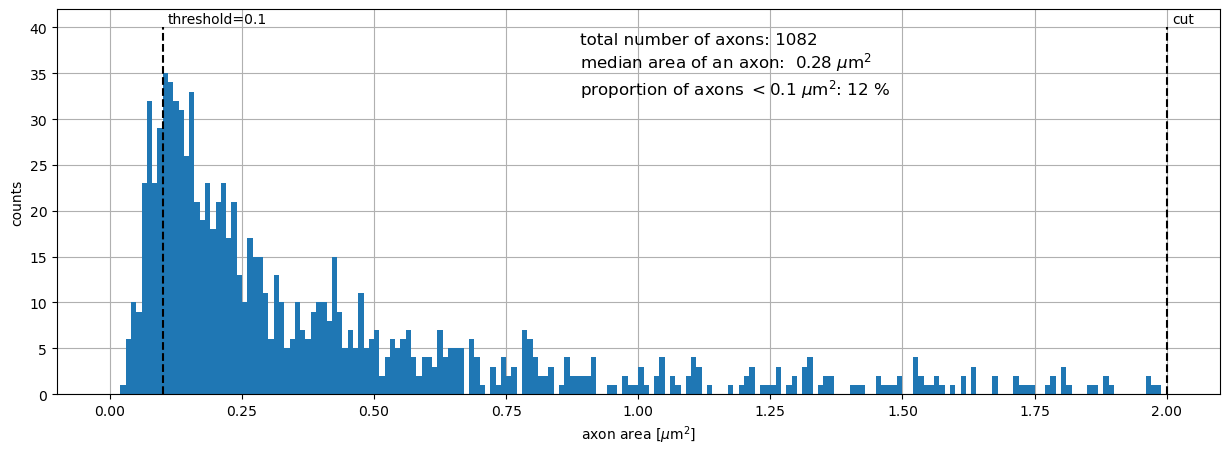

In [34]:
fig, ax = plt.subplots(figsize=(15, 5))
print(f"Smallest axon is : {df_axons.area.min():0.3f} $\mu$m$^2$")
print(f"Largest axon is : {df_axons.area.max():0.3f} $\mu$m$^2$")
#x_max = round(df_axons.area.max())
x_max = 2
output_hist = ax.hist(areas, np.arange(0, x_max, 0.01), log=False, density=False, zorder=2)
## Cut line:
ax.vlines(THR_DETECT, 0, 40, color='black', linestyle='dashed', linewidth=1.5)
ax.text(0.11, 40.5, f"threshold={THR_DETECT}")
## Threshold line:
ax.vlines(x_max, 0, 40, color='black', linestyle='dashed', linewidth=1.5)
ax.text(x_max+0.01, 40.5, f"cut")
ax.set_ylabel('counts')
ax.set_xlabel(r'axon area [$\mu$m$^2$]')
textstr = '\n'.join((
f'total number of axons: {len(df_axons)}',
f'median area of an axon: {df_axons.area.median(): .2f} $\mu$m$^2$',
f'proportion of axons $< {THR_DETECT} \ \mu$m$^2$: {df_axons.smaller_than_thr.sum()/len(df_axons)*100:.0f} %'
))
ax.text(0.45, 0.94, textstr, transform=ax.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left')
#ax.set_title()
#ax.set_ylim(ymin=0, ymax=300)
#ax.set_xlim(xmin=0, xmax=6)
ax.grid()

path2save = os.path.join(path2plots, f"axon_sizes_distribution_Hr11_electrosample_cut_at_{x_max}.png")
print(f"Saving plot in following location: {path2save}")
fig.savefig(path2save, facecolor='white')